In [1]:
from sunflower.utils import setup_notebook

setup_notebook(
    device=0,
    tmp_dir="/local/scratch/carlyn.1/tmp",
    hf_cache_dir="/local/scratch/carlyn.1/hf_cache"
)

In [2]:
from sunflower.models import DINOv2FeatureExtractor, DINOFeatureExtractionType
from sunflower.utils import HF_MODELS

dino = DINOv2FeatureExtractor(hf_path=HF_MODELS.DINOV2_BASE, extraction_type=DINOFeatureExtractionType.PATCH).cuda()
dino.eval()



/home/carlyn.1/code/sunflower/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


DINOv2FeatureExtractor(
  (image_encoder): Dinov2Model(
    (embeddings): Dinov2Embeddings(
      (patch_embeddings): Dinov2PatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(14, 14), stride=(14, 14))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): Dinov2Encoder(
      (layer): ModuleList(
        (0-11): 12 x Dinov2Layer(
          (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (attention): Dinov2Attention(
            (attention): Dinov2SelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): Dinov2SelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (layer_scale1): Dinov2Lay

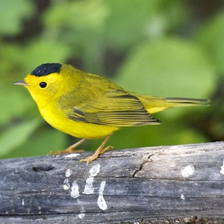

In [30]:
from PIL import Image

image = Image.open("../../assets/sunflower_1.JPG").resize((224, 224))
x = 410
y = 200
w = 300
h = 300
image = Image.open("../../output.png").crop((x, y, x + w, y + h)).resize((224, 224))
image

In [31]:
input_tensor = dino.preprocess_image(image).unsqueeze(0).cuda()
features = dino.forward_spatial(input_tensor)[0]
features.shape

torch.Size([256, 768])

In [41]:
import numpy as np
import cv2 as cv
 
Z = features.detach().cpu().numpy()
 
# convert to np.float32
Z = np.float32(Z)
 
# define criteria, number of clusters(K) and apply kmeans()
criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 10, 1.0)
K = 20
ret,label,center=cv.kmeans(Z,K,None,criteria,10,cv.KMEANS_RANDOM_CENTERS)
 
# Now convert back into uint8, and make original image
center = np.uint8(center)
res = center[label.flatten()]
res = res.reshape((16, 16, 768))

res[:2, :2, :2]

array([[[3, 0],
        [2, 0]],

       [[2, 0],
        [2, 0]]], dtype=uint8)

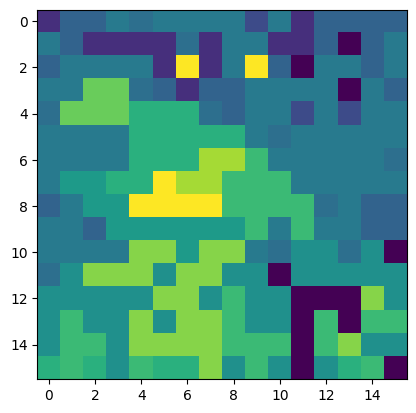

In [42]:
import matplotlib.pyplot as plt

show_img = res.astype(np.float32).mean(2).astype(np.uint8)

plt.imshow(show_img)

In [44]:
import torch
import torchvision.transforms.functional as F

heatmap = Image.fromarray(show_img).resize((224, 224), resample=Image.Resampling.NEAREST)

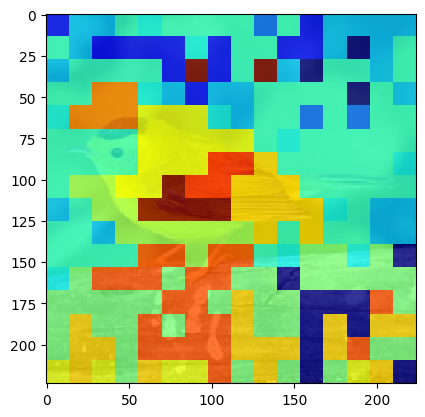

In [45]:
plt.figure()
plt.imshow(image, interpolation='none')
plt.imshow(heatmap, 'jet', interpolation='none', alpha=0.8)
plt.show()